![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Análisis de sentimientos y técnicas de NLP

En este taller podrán poner en práctica sus conocimientos sobre las diferentes técnicas para el procesamiento de lenguaje natural. El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción sentimientos de viajeros en Twitter

En este taller se usará el conjunto de datos de sentimientos sobre distintas aerolíneas de EE.UU. provenientes de Twitter. Cada observación contiene si el sentimiento de los tweets es positivo, neutral o negativo teniendo en cuenta distintas variables como aerolínea y las razones de los sentimientos negativos (como "retraso en el vuelo" o "servicio grosero"). El objetivo es predecir el sentimiento asociado a cada tweet. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/crowdflower/twitter-airline-sentiment).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación de librerías
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
# Lectura de la información de archivo .zip
tweets = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/Tweets.zip', index_col=0)

# Visualización dataset
tweets.head()

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
tweet_id,,,,,,,,,,,,,,
570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [4]:
# Impresión tamaño del cojunto de datos
tweets.shape

(14640, 14)

### Análisis descriptivo

In [5]:
# Cuenta de tweets por cada sentimiento
tweets['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

In [6]:
# Cuenta de tweets por cada aerolínea
tweets['airline'].value_counts()

airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

In [7]:
# Plot con cuenta de tweets por cada aerolínea y sentimiento
pd.crosstab(index = tweets["airline"],columns = tweets["airline_sentiment"]).plot(kind='bar',figsize=(10, 6),alpha=0.5,rot=0,stacked=True,title="Sentiminetos por aerolínea")

<Axes: title={'center': 'Sentiminetos por aerolínea'}, xlabel='airline'>

### Liberias y Variables de interés y predicción



In [8]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from nltk.stem.snowball import SnowballStemmer
from nltk.stem import WordNetLemmatizer

In [9]:
# Separación de variables predictoras (X) y de variable de interés (y)
X = tweets['text']
y = tweets['airline_sentiment'].map({'negative':-1,'neutral':0,'positive':1})

In [10]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Uso de CountVectorizer

En la celda 1 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [11]:
# Celda 1

# 1. Definimos el CountVectorizer básico
count_vect = CountVectorizer()

# 2. Realizamos las transformaciones necesarias para obtener la matriz de términos
X_train_cvect = count_vect.fit_transform(X_train)
X_test_cvect = count_vect.transform(X_test)

# 3. Definimos y Entrenamos el modelo de Random Forest con la matriz de términos obtenida
models = []
acc_scores = []

for n_estimators in [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]:
    rf_clf = RandomForestClassifier(n_estimators = n_estimators, random_state = 42)
    rf_clf.fit(X_train_cvect, y_train)
    models.append((n_estimators, rf_clf))
    y_pred = rf_clf.predict(X_test_cvect)
    acc_scores.append(accuracy_score(y_test, y_pred))

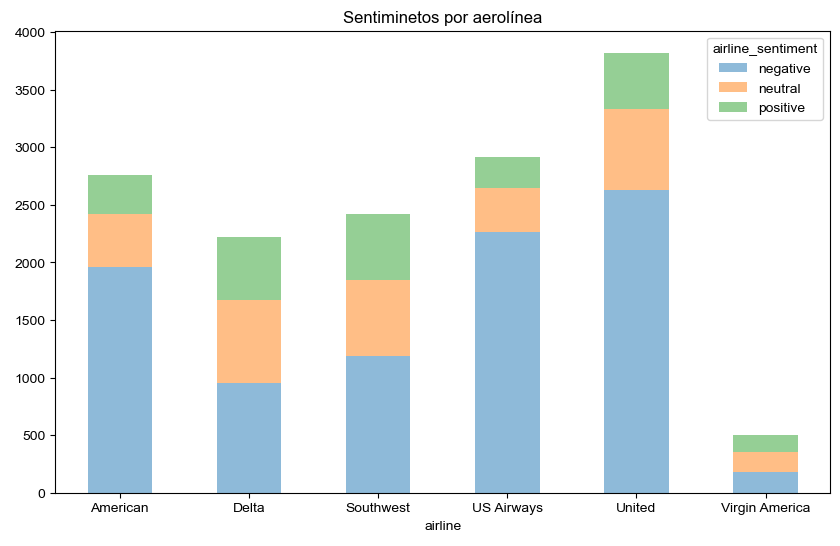

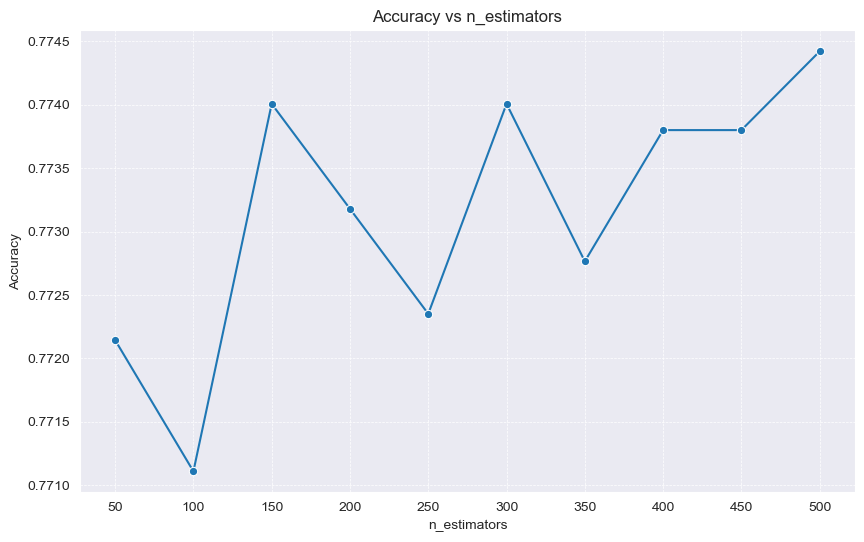

In [12]:
# 4. Predecimos y evaluamos el modelo
import seaborn as sns
sns.set_style('darkgrid')

plt.figure(figsize = (10, 6))
sns.lineplot(x=[n for n, _ in models], y = acc_scores, marker = 'o')
plt.title('Accuracy vs n_estimators')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.xticks([n for n, _ in models])
plt.grid(color='white', linestyle='--', linewidth = 0.5)
plt.show()

### Punto 2 - Eliminación de Stopwords

En la celda 2 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer, **eliminen stopwords** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [13]:
# Celda 2

# 1. Definimos el CountVectorizer básico
cvect_stop = CountVectorizer(stop_words='english')

# 2. Realizamos las transformaciones necesarias para obtener la matriz de términos
X_train_cvect = cvect_stop.fit_transform(X_train)
X_test_cvect = cvect_stop.transform(X_test)

# 3. Definimos y Entrenamos el modelo de Random Forest con la matriz de términos obtenida
models_st = []
acc_scores_st = []

for n_estimators in [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]:
    rf_clf_st = RandomForestClassifier(n_estimators = n_estimators, random_state = 42)
    rf_clf_st.fit(X_train_cvect, y_train)
    models_st.append((n_estimators, rf_clf_st))
    y_pred = rf_clf_st.predict(X_test_cvect)
    acc_scores_st.append(accuracy_score(y_test, y_pred))

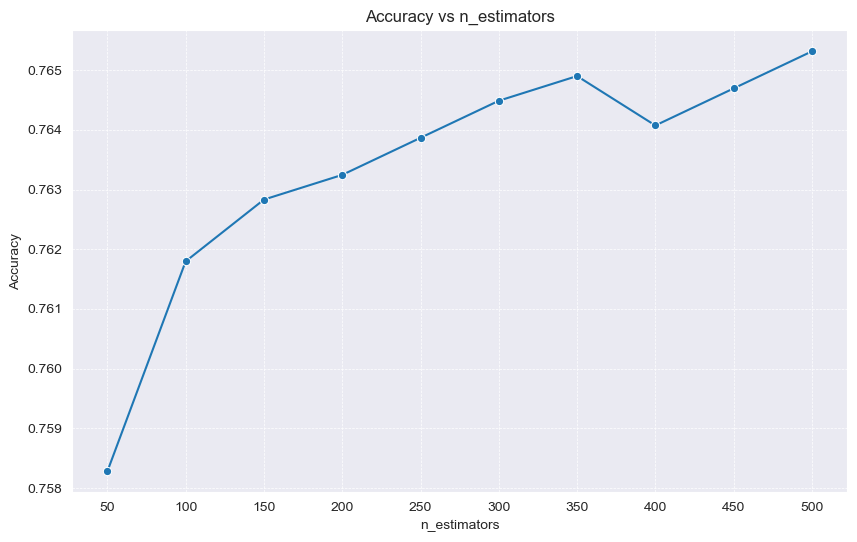

In [14]:
# 4. Predecimos y evaluamos el modelo
import seaborn as sns
sns.set_style('darkgrid')

plt.figure(figsize = (10, 6))
sns.lineplot(x=[n for n, _ in models_st], y = acc_scores_st, marker = 'o')
plt.title('Accuracy vs n_estimators')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.xticks([n for n, _ in models_st])
plt.grid(color='white', linestyle='--', linewidth = 0.5)
plt.show()

### Punto 3 - Lematización con verbos

En la celda 3 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer, **lematizen el texto con verbos** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [15]:
# Celda 3

# Importación de librerias
from nltk.stem import WordNetLemmatizer
wordnet_lemmatizer = WordNetLemmatizer()
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\57313\AppData\Roaming\nltk_data...


True

In [16]:
# Definición de la función que tenga como parámetro texto y devuelva una lista de lemas
def split_into_lemmas(text):
    text = text.lower()
    words = text.split()
    return [wordnet_lemmatizer.lemmatize(word,pos='v') for word in words]

In [17]:
# 1. Definimos el CountVectorizer básico usando el parámetro 'split_into_lemmas'
vect_lemas = CountVectorizer(analyzer=split_into_lemmas)

# 2. Realizamos las transformaciones necesarias para obtener la matriz de términos
X_train_vl = vect_lemas.fit_transform(X_train)
X_test_vl = vect_lemas.transform(X_test)

# 3. Definimos y Entrenamos el modelo de Random Forest con la matriz de términos obtenida
models_vl = []
acc_scores_vl = []

for n_estimators in [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]:
    rf_clf_vl = RandomForestClassifier(n_estimators = n_estimators, random_state = 42)
    rf_clf_vl.fit(X_train_vl, y_train)
    models_vl.append((n_estimators, rf_clf_vl))
    y_pred = rf_clf_vl.predict(X_test_vl)
    acc_scores_vl.append(accuracy_score(y_test, y_pred))

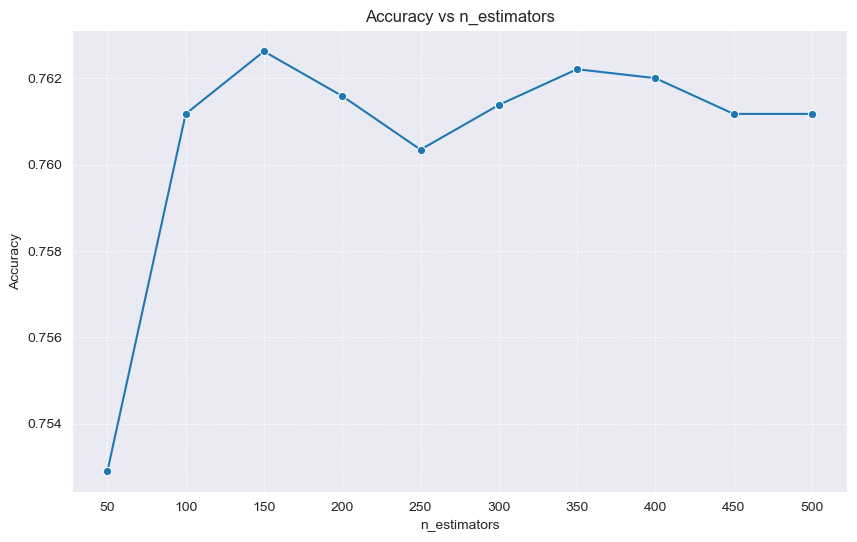

In [18]:
# 4. Predecimos y evaluamos el modelo
import seaborn as sns
sns.set_style('darkgrid')

plt.figure(figsize = (10, 6))
sns.lineplot(x=[n for n, _ in models_vl], y = acc_scores_vl, marker = 'o')
plt.title('Accuracy vs n_estimators')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.xticks([n for n, _ in models_vl])
plt.grid(color='white', linestyle='--', linewidth = 0.5)
plt.show()

### Punto 4 - Multiples técnicas

En la celda 4 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer, eliminen stopwords, lematizen el texto con verbos** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [19]:
# Celda 4

# Cargamos las stop words una sola vez fuera de la función por eficiencia
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words_en = set(stopwords.words('english'))

def split_into_lemmas_sw(text):
    text = text.lower()
    words = text.split()

    # Creamos los lemas de los verbos
    lemmas = [wordnet_lemmatizer.lemmatize(word, pos='v') for word in words]

    # Retornamos el lema solo si no es una stopword
    return [l for l in lemmas if l not in stop_words_en]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\57313\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [24]:
# 1. Definimos el CountVectorizer básico usando el parámetro 'split_into_lemmas_sw'
vect_lemas_sw = CountVectorizer(analyzer=split_into_lemmas_sw)

# 2. Realizamos las transformaciones necesarias para obtener la matriz de términos
X_train_vl_sw = vect_lemas_sw.fit_transform(X_train)
X_test_vl_sw = vect_lemas_sw.transform(X_test)

# 3. Definimos y Entrenamos el modelo de Random Forest con la matriz de términos obtenida
models_vl_sw = []
acc_scores_vl_sw = []

rf_clf_vl_sw = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1,
    warm_start=True  # ← corregido el typo
)

for n_estimators in [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]:
    rf_clf_vl_sw.n_estimators = n_estimators  # ← solo actualizamos el número de árboles
    rf_clf_vl_sw.fit(X_train_vl_sw, y_train)
    models_vl_sw.append((n_estimators, rf_clf_vl_sw))
    y_pred = rf_clf_vl_sw.predict(X_test_vl_sw)
    acc_scores_vl_sw.append(accuracy_score(y_test, y_pred))

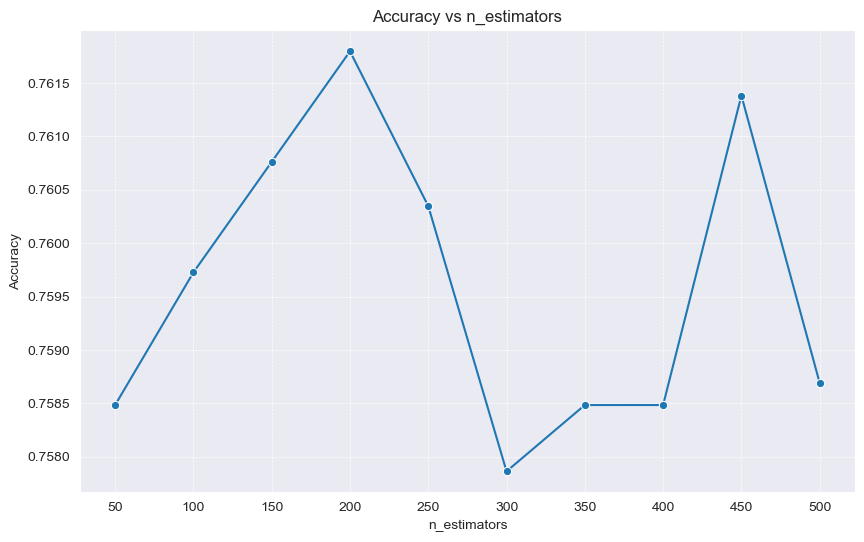

In [25]:
# 4. Predecimos y evaluamos el modelo
import seaborn as sns
sns.set_style('darkgrid')

plt.figure(figsize = (10, 6))
sns.lineplot(x=[n for n, _ in models_vl_sw], y = acc_scores_vl_sw, marker = 'o')
plt.title('Accuracy vs n_estimators')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.xticks([n for n, _ in models_vl_sw])
plt.grid(color='white', linestyle='--', linewidth = 0.5)
plt.show()

### Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos (random forest) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

Cuando comparamos los diferentes modelos implementados, pudimos observar que el mejor desempeño se obtiene utilizando CountVectorizer sin aplicar técnicas adicionales de preprocesamiento, alcanzando un accuracy aproximado de 0.775. Por otro lado, encontramos que el modelo con menor desempeño corresponde al que combina lematización de verbos y eliminación de stopwords,
con un accuracy cercano a 0.761.

Una de las principales ventajas del modelo con mejor desempeño es que conserva toda la información original del texto, incluyendo palabras que pueden parecer irrelevantes pero que en tareas de análisis de sentimiento, como las negaciones ("not", "no"), resultan fundamentales para interpretar correctamente el contexto. Además,
al no aplicar transformaciones adicionales, podemos evitar la pérdida de información semántica y mantenemos la riqueza del lenguaje presente en los tweets.

En contraste, el modelo con menor desempeño presenta como desventaja principal la pérdida de información relevante debido al preprocesamiento. La eliminación de stopwords puede descartar términos clave para la clasificación del sentimiento, mientras que la lematización puede simplificar en exceso las palabras,
eliminando matices importantes, especialmente en textos informales como los tweets. Lo que termina afectando negativamente la capacidad del modelo para discriminar correctamente entre las clases.

Para este caso particular, aunque técnicas como la lematización y la eliminación de stopwords suelen ser útiles en otros contextos de procesamiento de lenguaje natural, en este caso particular su aplicación no mejora el desempeño del modelo, evidenciando que un enfoque más simple puede ser más efectivo para este tipo de datos.
